In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import dask.dataframe as dd
from dask.distributed import Client
client = Client()  # Automatically uses available cores
client

c:\Users\apoor\anaconda3\Lib\site-packages\distributed\node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 54556 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:54556/status,
Dashboard: http://127.0.0.1:54556/status,Workers: 4
Total threads: 16,Total memory: 15.86 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:54557,Workers: 0
Dashboard: http://127.0.0.1:54556/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:54576,Total threads: 4
Dashboard: http://127.0.0.1:54581/status,Memory: 3.96 GiB
Nanny: tcp://127.0.0.1:54560,


2025-10-28 00:33:01,922 - distributed.scheduler - WARNING - Worker failed to heartbeat for 17997s; attempting restart: <WorkerState 'tcp://127.0.0.1:54576', name: 0, status: running, memory: 0, processing: 0>
2025-10-28 00:33:01,970 - distributed.scheduler - WARNING - Worker failed to heartbeat for 17997s; attempting restart: <WorkerState 'tcp://127.0.0.1:54577', name: 2, status: running, memory: 0, processing: 0>
2025-10-28 00:33:01,972 - distributed.scheduler - WARNING - Worker failed to heartbeat for 17997s; attempting restart: <WorkerState 'tcp://127.0.0.1:54578', name: 3, status: running, memory: 0, processing: 0>
2025-10-28 00:33:06,075 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2025-10-28 00:33:06,077 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2025-10-28 00:33:06,082 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
2025-10-28 00:33:07,179 - distributed.core 

In [12]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
import joblib
import os

In [ ]:
# ---------------- CONFIG ----------------
data_dir = r"D:\datascience\campusx\PROJECTS\demand_preidction_experimentation\data\final_dataset_parquet.parquet"
scaler_path = r"D:\datascience\campusx\PROJECTS\demand_preidction_experimentation\data\scaler.pkl"
model_path = r"D:\datascience\campusx\PROJECTS\demand_preidction_experimentation\data\kmeans_model.pkl"
N_CLUSTERS = 30
RANDOM_STATE = 42

In [13]:
# ---------------- STEP 1: Collect all parquet parts ----------------
parquet_files = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith(".parquet")]
parquet_files.sort()
print(f"📦 Found {len(parquet_files)} parquet parts.")

📦 Found 82 parquet parts.


In [15]:
# ---------------- STEP 2: Fit StandardScaler incrementally ----------------
scaler = StandardScaler()
print("\n🧩 Step 1: Fitting StandardScaler incrementally...")

for i, file_path in enumerate(parquet_files):
    df_chunk = pd.read_parquet(file_path, engine="pyarrow", columns=["pickup_latitude", "pickup_longitude"])
    df_chunk = df_chunk.dropna()

    if not df_chunk.empty:
        scaler.partial_fit(df_chunk)
    
    if (i + 1) % 10 == 0 or i == len(parquet_files) - 1:
        print(f"  ✅ Processed {i + 1}/{len(parquet_files)} files")

print("Scaler fitted successfully!")
print("Mean:", scaler.mean_)
print("Scale:", scaler.scale_)
joblib.dump(scaler, scaler_path)
print(f"💾 Scaler saved to: {scaler_path}")



🧩 Step 1: Fitting StandardScaler incrementally...
  ✅ Processed 10/82 files
  ✅ Processed 20/82 files
  ✅ Processed 30/82 files
  ✅ Processed 40/82 files
  ✅ Processed 50/82 files
  ✅ Processed 60/82 files
  ✅ Processed 70/82 files
  ✅ Processed 80/82 files
  ✅ Processed 82/82 files
Scaler fitted successfully!
Mean: [ 40.75107121 -73.9740618 ]
Scale: [0.02722268 0.03675237]
💾 Scaler saved to: D:\datascience\campusx\PROJECTS\demand_preidction_experimentation\data\scaler.pkl


In [16]:

# ---------------- STEP 3: Train MiniBatchKMeans incrementally ----------------
print("\n🧠 Step 2: Training MiniBatchKMeans incrementally...")

mini_batch = MiniBatchKMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=RANDOM_STATE)

for i, file_path in enumerate(parquet_files):
    df_chunk = pd.read_parquet(file_path, engine="pyarrow", columns=["pickup_latitude", "pickup_longitude"])
    df_chunk = df_chunk.dropna()

    if not df_chunk.empty:
        scaled_chunk = scaler.transform(df_chunk)
        mini_batch.partial_fit(scaled_chunk)
    
    if (i + 1) % 10 == 0 or i == len(parquet_files) - 1:
        print(f"  ✅ Trained on {i + 1}/{len(parquet_files)} files")


🧠 Step 2: Training MiniBatchKMeans incrementally...
  ✅ Trained on 10/82 files
  ✅ Trained on 20/82 files
  ✅ Trained on 30/82 files
  ✅ Trained on 40/82 files
  ✅ Trained on 50/82 files
  ✅ Trained on 60/82 files
  ✅ Trained on 70/82 files
  ✅ Trained on 80/82 files
  ✅ Trained on 82/82 files


In [17]:
print("MiniBatchKMeans trained successfully!")
centroids = scaler.inverse_transform(mini_batch.cluster_centers_)
print("Centroids shape:", centroids.shape)

joblib.dump(mini_batch, model_path)
print(f"💾 Model saved to: {model_path}")

MiniBatchKMeans trained successfully!
Centroids shape: (30, 2)
💾 Model saved to: D:\datascience\campusx\PROJECTS\demand_preidction_experimentation\data\kmeans_model.pkl


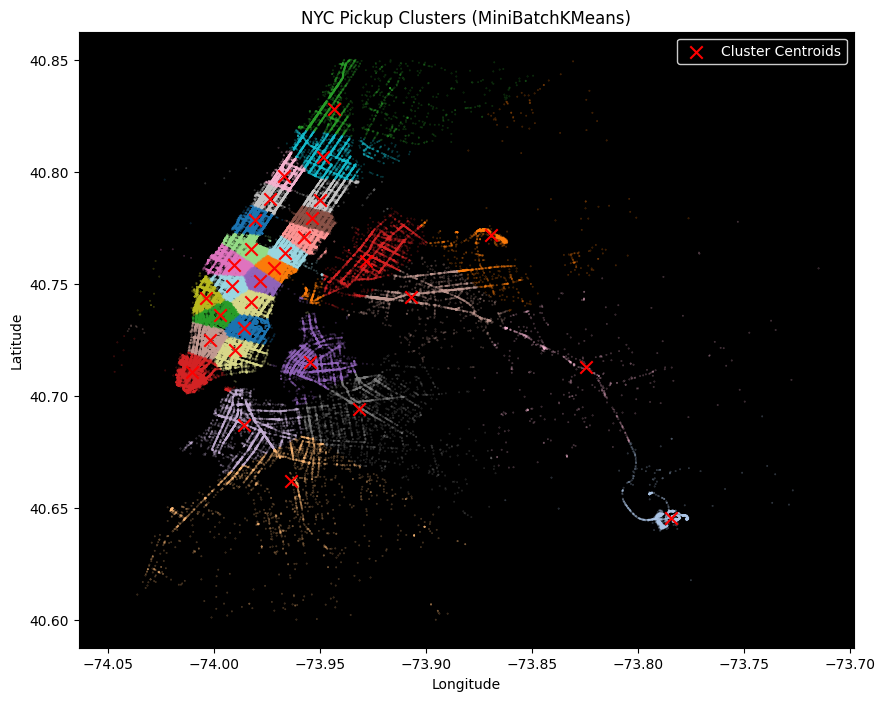

In [21]:
# ============================================================
# 🎨 Step 3.5: Visualize MiniBatchKMeans Clusters
# ============================================================
import matplotlib.pyplot as plt

# Inverse-transform centroids (to get back real lat-long)
centroids = scaler.inverse_transform(mini_batch.cluster_centers_)

# Load one small sample (e.g. 1 parquet part) to visualize
sample_df = pd.read_parquet(parquet_files[0], engine="pyarrow", columns=["pickup_latitude", "pickup_longitude"])
sample_df = sample_df.dropna()

# Scale and predict cluster labels for sample
scaled_sample = scaler.transform(sample_df)
sample_df["region"] = mini_batch.predict(scaled_sample)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_facecolor("black")

# Scatter points (pickups)
ax.scatter(
    sample_df["pickup_longitude"],
    sample_df["pickup_latitude"],
    s=0.1,
    c=sample_df["region"],
    cmap="tab20",
    alpha=0.4
)

# Overlay cluster centroids
ax.scatter(
    centroids[:, 1],  # longitude
    centroids[:, 0],  # latitude
    c="red",
    s=80,
    marker="x",
    label="Cluster Centroids"
)

ax.set_title("NYC Pickup Clusters (MiniBatchKMeans)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(facecolor="black", edgecolor="white", labelcolor="white")
ax.grid(False)
plt.show()


In [23]:
# ---------------- STEP 4: Assign clusters to all rows ----------------
print("\n📍 Step 3: Assigning region (cluster) IDs to each pickup...")

output_chunks = []
for i, file_path in enumerate(parquet_files):
    df_chunk = pd.read_parquet(file_path, engine="pyarrow")
    coords = df_chunk[["pickup_latitude", "pickup_longitude"]].fillna(np.nan)

    # Assign clusters
    valid_mask = coords.notnull().all(axis=1)
    cluster_labels = np.full(len(coords), -1, dtype=int)
    
    if valid_mask.any():
        scaled_vals = scaler.transform(coords.loc[valid_mask, :])
        cluster_labels[valid_mask.values] = mini_batch.predict(scaled_vals)

    df_chunk["region"] = cluster_labels
    output_chunks.append(df_chunk)

    if (i + 1) % 10 == 0 or i == len(parquet_files) - 1:
        print(f"  ✅ Assigned clusters to {i + 1}/{len(parquet_files)} files")


📍 Step 3: Assigning region (cluster) IDs to each pickup...
  ✅ Assigned clusters to 10/82 files
  ✅ Assigned clusters to 20/82 files
  ✅ Assigned clusters to 30/82 files
  ✅ Assigned clusters to 40/82 files
  ✅ Assigned clusters to 50/82 files
  ✅ Assigned clusters to 60/82 files
  ✅ Assigned clusters to 70/82 files
  ✅ Assigned clusters to 80/82 files
  ✅ Assigned clusters to 82/82 files


In [25]:
# Combine all chunks (if it fits in memory)
df_final = pd.concat(output_chunks, ignore_index=True)
print(f"Final dataset shape with regions: {df_final.shape}")

Final dataset shape with regions: (33234199, 4)


In [27]:
# ---------------- STEP 5: Prepare time-series dataset ----------------
print("\n🕒 Step 4: Preparing and saving time-series dataset (Parquet version)...")

# Drop latitude and longitude (inplace = saves memory)
df_final.drop(columns=["pickup_latitude", "pickup_longitude"], inplace=True)

# Define Parquet save path
save_path = r"D:\datascience\campusx\PROJECTS\demand_preidction_experimentation\data\time_series.parquet"

# Save the file in Parquet format
df_final.to_parquet(save_path, index=False, engine="pyarrow")

print(f"💾 Time-series dataset saved successfully at:\n{save_path}")


🕒 Step 4: Preparing and saving time-series dataset (Parquet version)...
💾 Time-series dataset saved successfully at:
D:\datascience\campusx\PROJECTS\demand_preidction_experimentation\data\time_series.parquet


In [28]:
time_series_data = pd.read_parquet(
    r"D:\datascience\campusx\PROJECTS\demand_preidction_experimentation\data\time_series.parquet"
)

print(time_series_data.shape)
time_series_data.head()

(33234199, 2)


,tpep_pickup_datetime,region
0,2016-01-01 00:00:00,6
1,2016-01-01 00:00:00,1
2,2016-01-01 00:00:00,14
3,2016-01-01 00:00:00,25
4,2016-01-01 00:00:00,15


# Pickup Calculation


In [29]:
# group the time series data based on regions

region_grp = time_series_data.groupby("region")

region_grp

In [30]:
# check for missing values

time_series_data.isna().sum()

tpep_pickup_datetime    0
region                  0
dtype: int64

In [40]:
import pyarrow.parquet as pq
data_path = r"D:\datascience\campusx\PROJECTS\demand_preidction_experimentation\data\time_series.parquet"


In [43]:
# ============================
# ⚙️ Helper function
# ============================
def process_chunk(df):
    """Convert datetime and resample in 15-minute intervals per region."""
    df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"], errors="coerce", cache=False)
    df = df.dropna(subset=["tpep_pickup_datetime"])
    df = df.set_index("tpep_pickup_datetime")

    resampled = (
        df.groupby("region")
          .resample("15min")
          .size()
          .reset_index(name="pickup_count")
    )
    return resampled

In [ ]:
# ============================
# 🚀 Step 1: Initialize reader
# ============================
parquet_file = pq.ParquetFile(data_path)

batch_size = 100_000  # rows per batch
aggregated_results = []

print("📦 Processing data in small PyArrow batches...")

# ============================
# 🔁 Step 2: Stream through file
# ============================
for i, batch in enumerate(parquet_file.iter_batches(batch_size=batch_size)):
    print(f"🔹 Processing batch {i+1}")
    
    # Convert to pandas DataFrame
    chunk = batch.to_pandas()
    
    # Process chunk
    resampled_chunk = process_chunk(chunk)
    aggregated_results.append(resampled_chunk)
    
    # Free memory
    del chunk, resampled_chunk

In [49]:
# ============================
# 🧩 Step 3: Combine results
# ============================
print("\n🧩 Combining all partial results...")
final_resampled = pd.concat(aggregated_results, ignore_index=True)

# Merge overlapping (same region + time) bins
final_resampled = (
    final_resampled
    .groupby(["region", "tpep_pickup_datetime"])["pickup_count"]
    .sum()
    .reset_index()
)

print("✅ Combined data shape:", final_resampled.shape)


🧩 Combining all partial results...
✅ Combined data shape: (262080, 3)


In [50]:
final_resampled.rename(columns={'pickup_count': 'total_pickups'}, inplace=True)

In [58]:
final_resampled=final_resampled[['tpep_pickup_datetime','region','total_pickups']].set_index('tpep_pickup_datetime')
final_resampled.head()

,region,total_pickups
tpep_pickup_datetime,,
2016-01-01 00:00:00,0,138
2016-01-01 00:15:00,0,326
2016-01-01 00:30:00,0,235
2016-01-01 00:45:00,0,241
2016-01-01 01:00:00,0,250


In [59]:
(final_resampled['total_pickups'] == 0).sum()

3966

In [60]:
epsilon_val = 10
final_resampled.replace({'total_pickups': {0 : epsilon_val}}, inplace=True)

In [63]:
final_resampled.shape

(262080, 2)

# Moving Average


🪟 Window values to test: [3, 4, 5, 6, 7, 8, 9, 10]


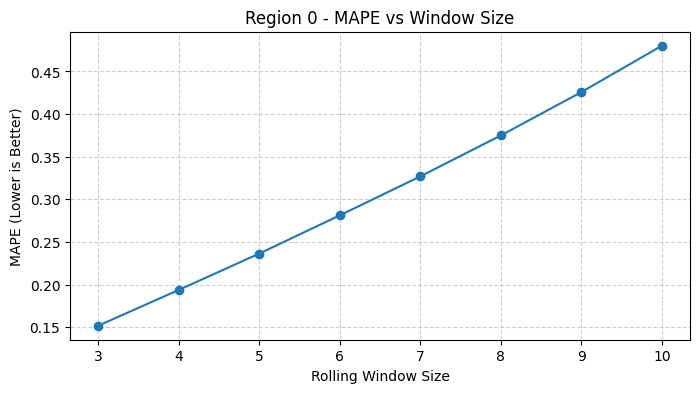

✅ Region 0: Best window = 3 → MAPE = 0.1517
--------------------------------------------------


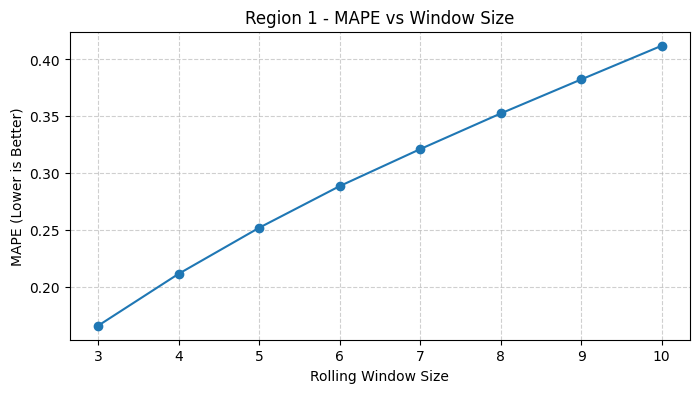

✅ Region 1: Best window = 3 → MAPE = 0.1661
--------------------------------------------------


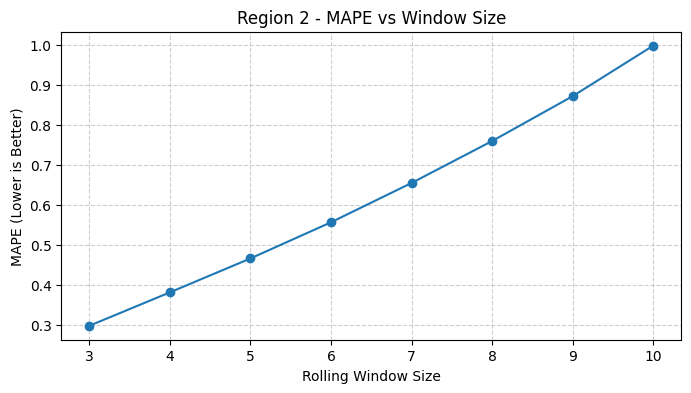

✅ Region 2: Best window = 3 → MAPE = 0.2973
--------------------------------------------------


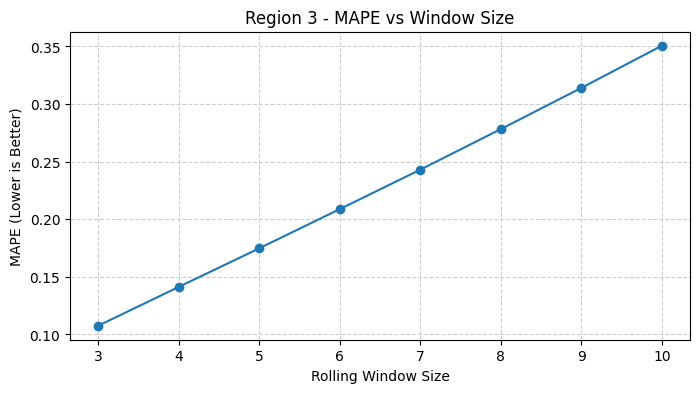

✅ Region 3: Best window = 3 → MAPE = 0.1076
--------------------------------------------------


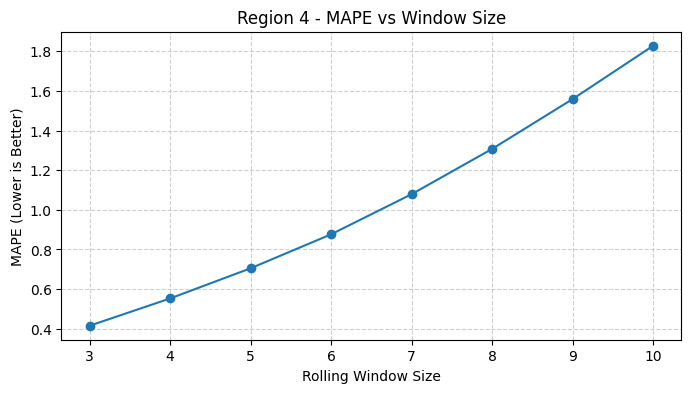

✅ Region 4: Best window = 3 → MAPE = 0.4149
--------------------------------------------------


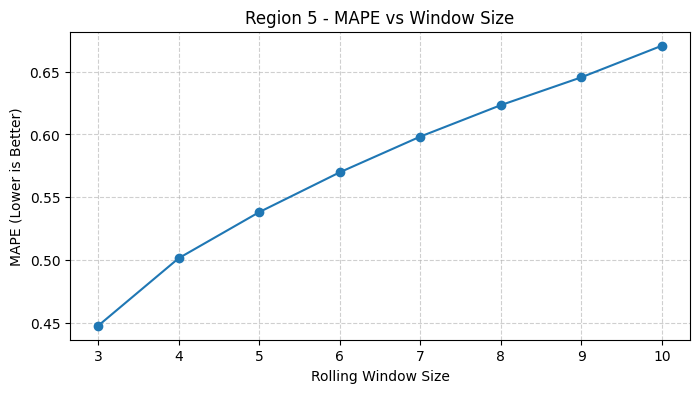

✅ Region 5: Best window = 3 → MAPE = 0.4475
--------------------------------------------------


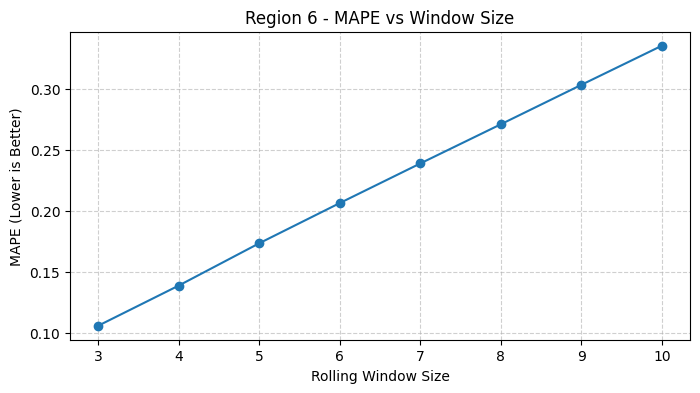

✅ Region 6: Best window = 3 → MAPE = 0.1057
--------------------------------------------------


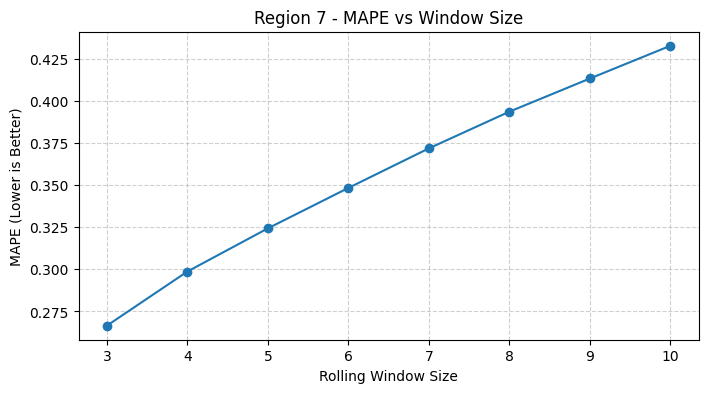

✅ Region 7: Best window = 3 → MAPE = 0.2665
--------------------------------------------------


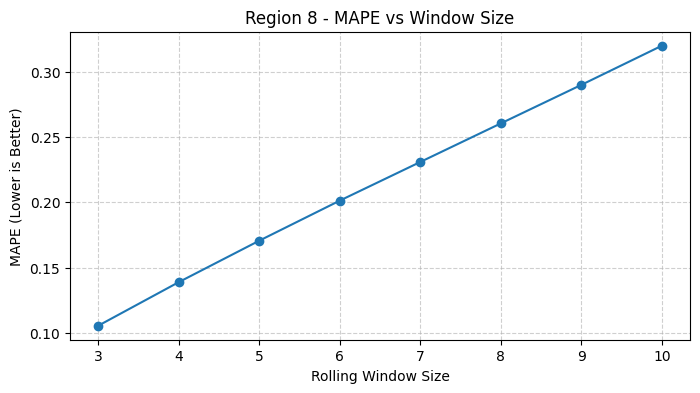

✅ Region 8: Best window = 3 → MAPE = 0.1055
--------------------------------------------------


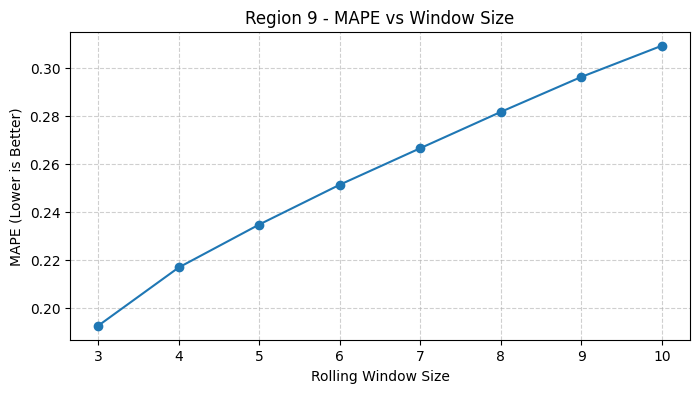

✅ Region 9: Best window = 3 → MAPE = 0.1925
--------------------------------------------------


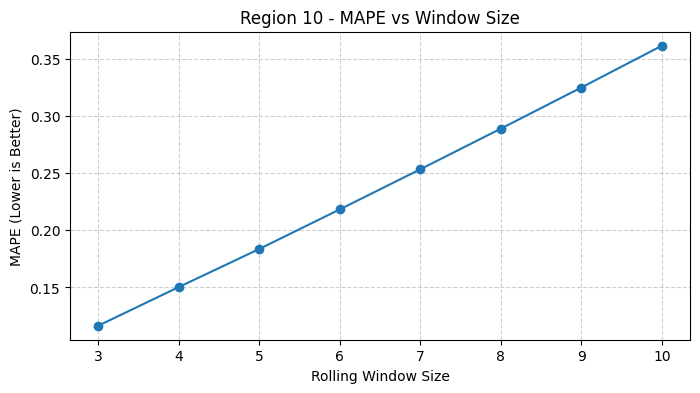

✅ Region 10: Best window = 3 → MAPE = 0.1165
--------------------------------------------------


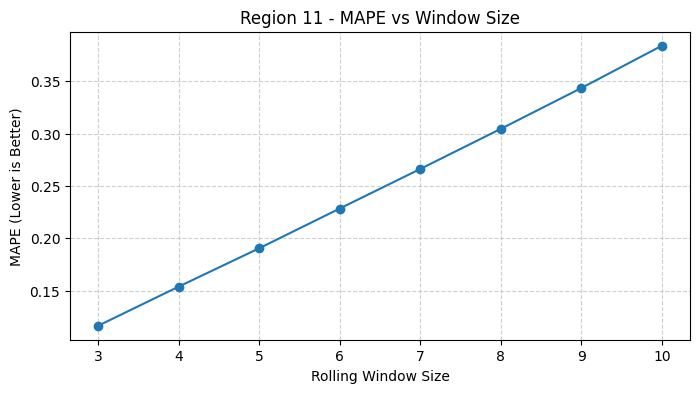

✅ Region 11: Best window = 3 → MAPE = 0.1166
--------------------------------------------------


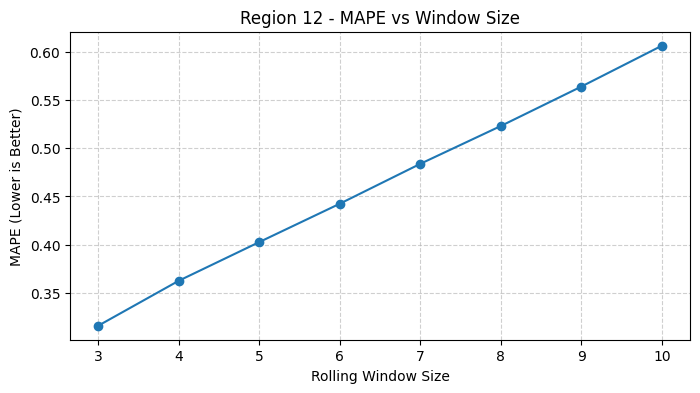

✅ Region 12: Best window = 3 → MAPE = 0.3159
--------------------------------------------------


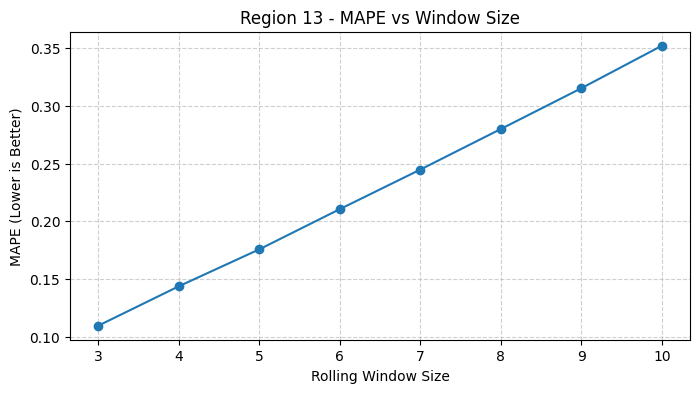

✅ Region 13: Best window = 3 → MAPE = 0.1097
--------------------------------------------------


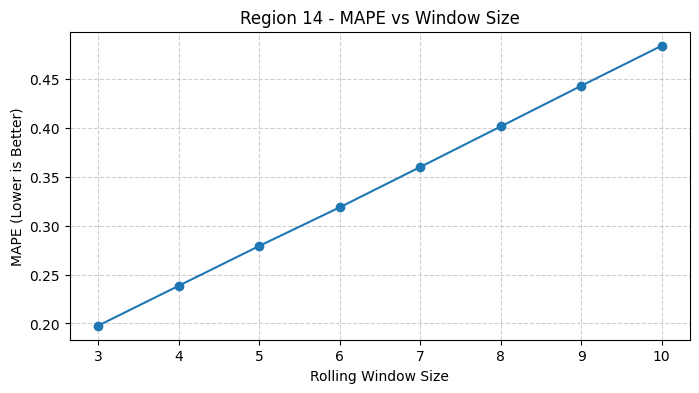

✅ Region 14: Best window = 3 → MAPE = 0.1976
--------------------------------------------------


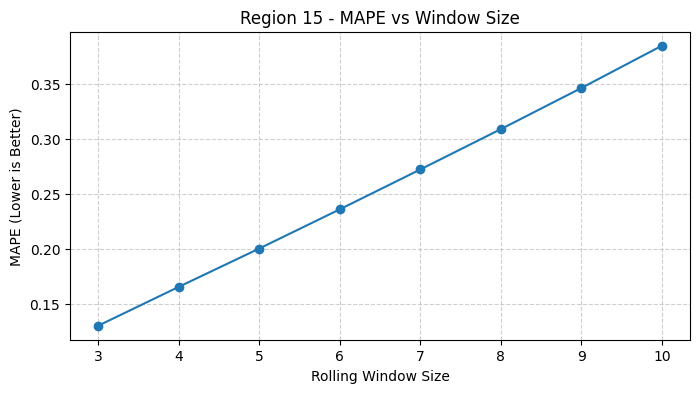

✅ Region 15: Best window = 3 → MAPE = 0.1306
--------------------------------------------------


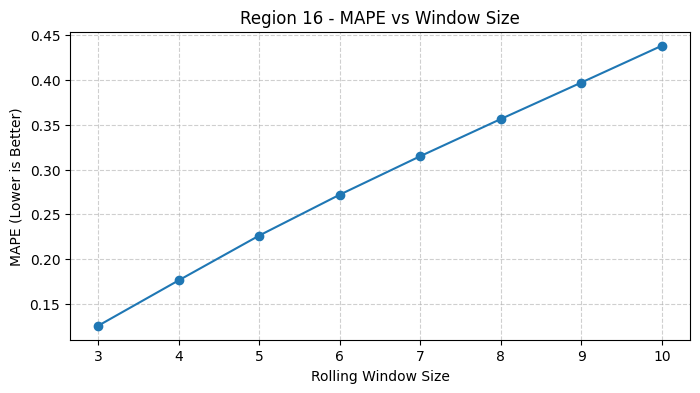

✅ Region 16: Best window = 3 → MAPE = 0.1259
--------------------------------------------------


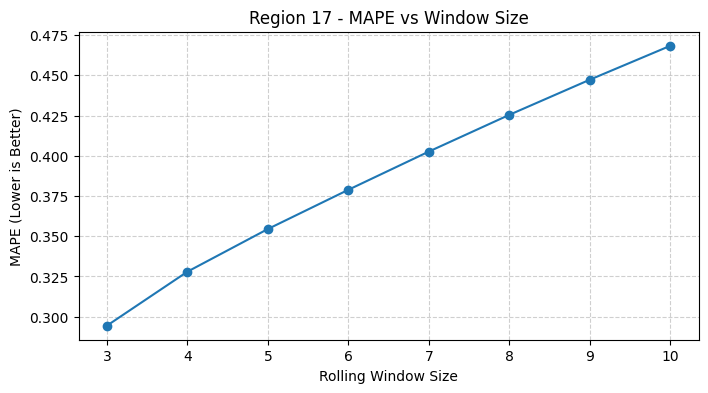

✅ Region 17: Best window = 3 → MAPE = 0.2943
--------------------------------------------------


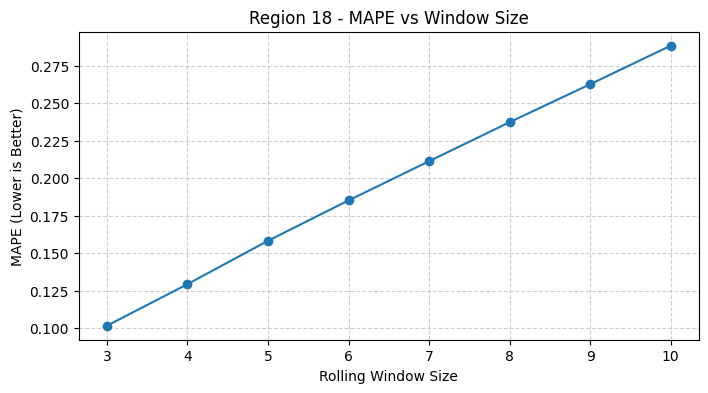

✅ Region 18: Best window = 3 → MAPE = 0.1015
--------------------------------------------------


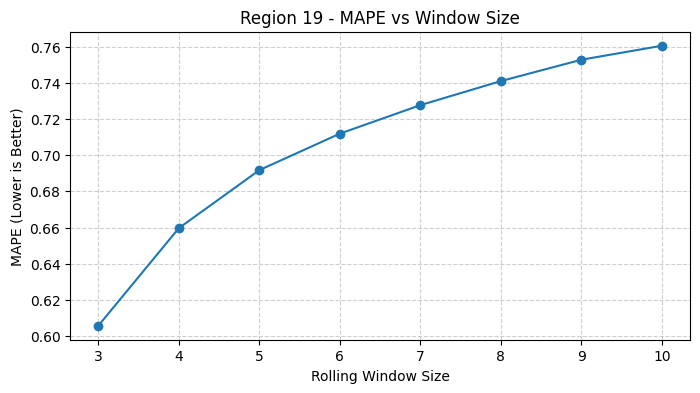

✅ Region 19: Best window = 3 → MAPE = 0.6057
--------------------------------------------------


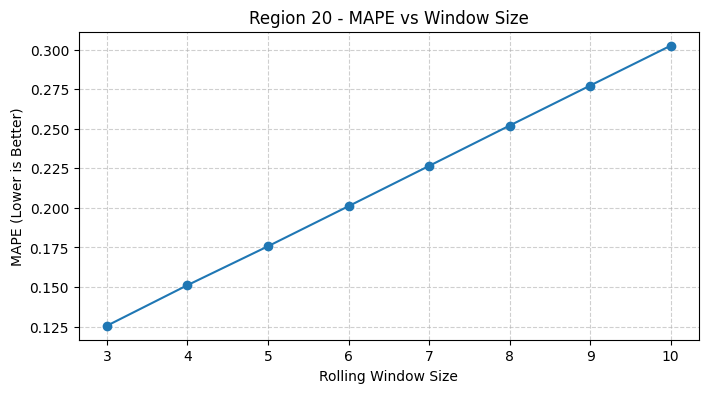

✅ Region 20: Best window = 3 → MAPE = 0.1256
--------------------------------------------------


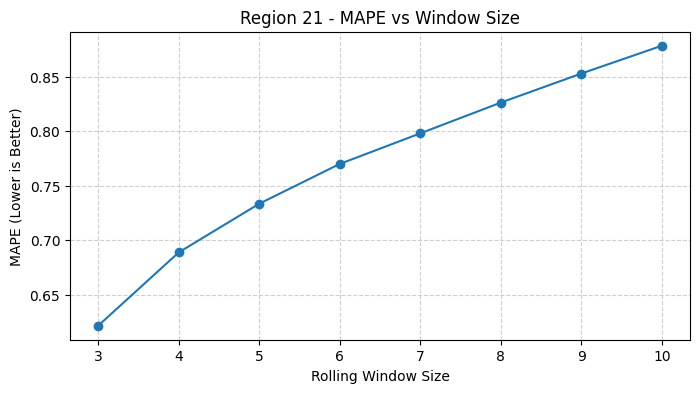

✅ Region 21: Best window = 3 → MAPE = 0.6216
--------------------------------------------------


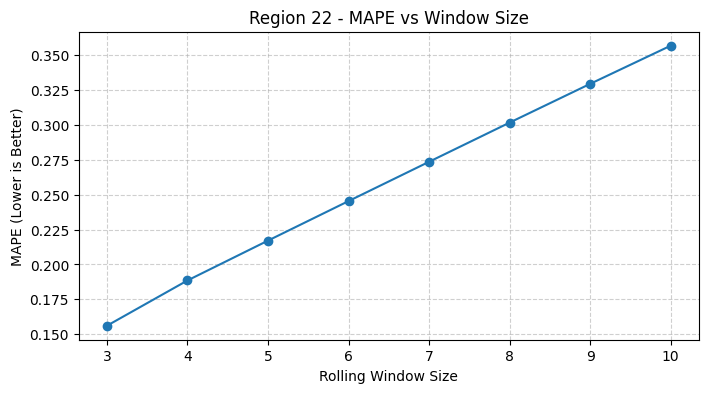

✅ Region 22: Best window = 3 → MAPE = 0.1561
--------------------------------------------------


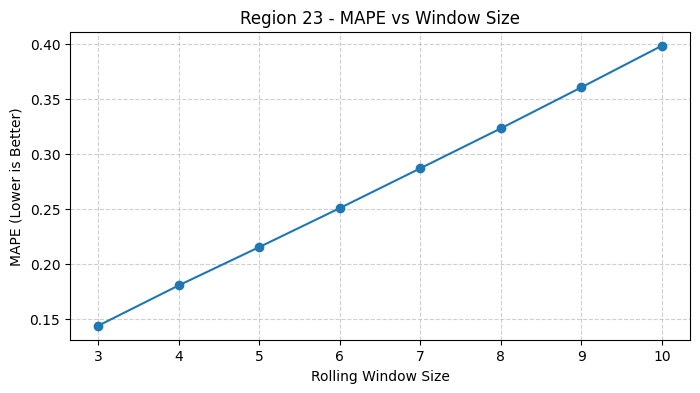

✅ Region 23: Best window = 3 → MAPE = 0.1437
--------------------------------------------------


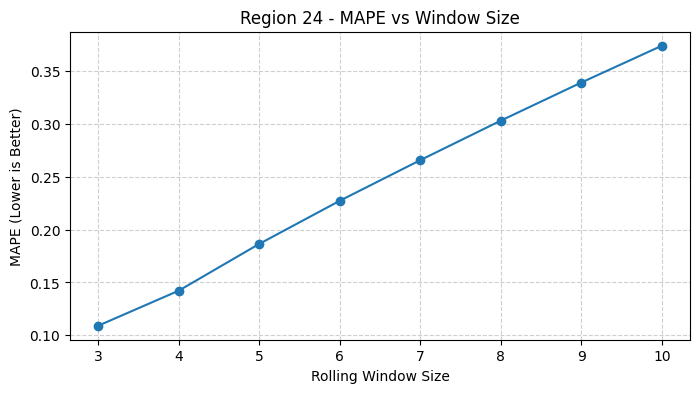

✅ Region 24: Best window = 3 → MAPE = 0.1090
--------------------------------------------------


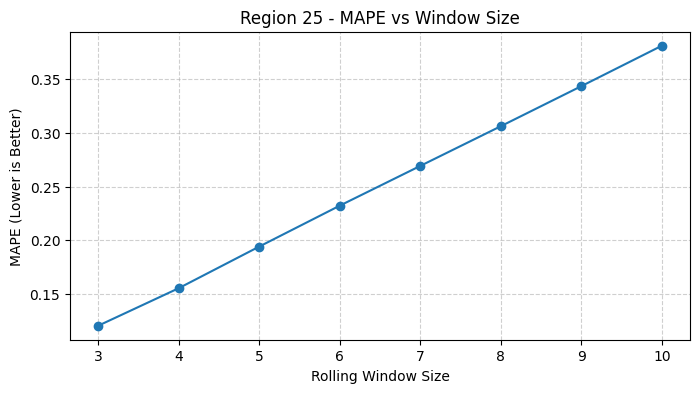

✅ Region 25: Best window = 3 → MAPE = 0.1207
--------------------------------------------------


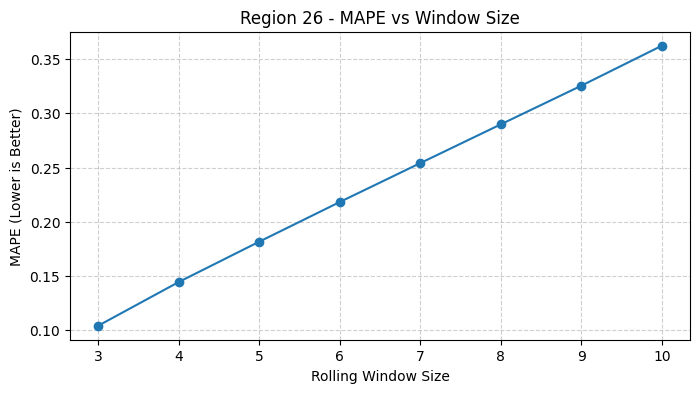

✅ Region 26: Best window = 3 → MAPE = 0.1042
--------------------------------------------------


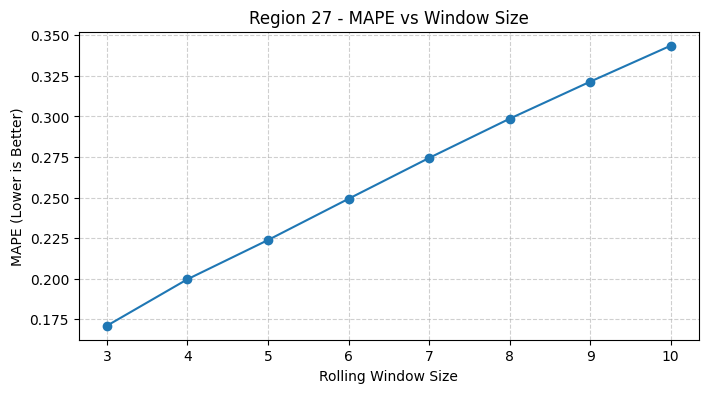

✅ Region 27: Best window = 3 → MAPE = 0.1710
--------------------------------------------------


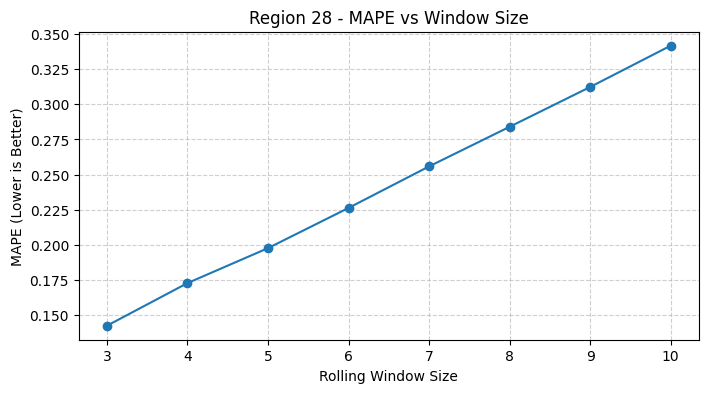

✅ Region 28: Best window = 3 → MAPE = 0.1422
--------------------------------------------------


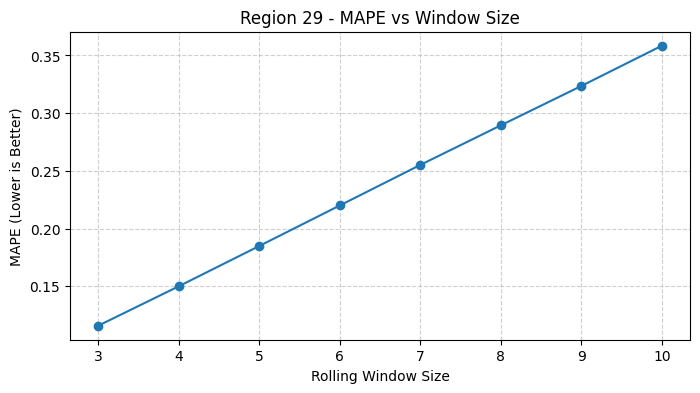

✅ Region 29: Best window = 3 → MAPE = 0.1158
--------------------------------------------------

📊 Summary of Best Windows per Region:
    region  best_window  best_mape
18      18            3   0.101529
26      26            3   0.104234
8        8            3   0.105509
6        6            3   0.105651
3        3            3   0.107556
24      24            3   0.109032
13      13            3   0.109673
29      29            3   0.115761
10      10            3   0.116530
11      11            3   0.116570


In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error

# --------------------------------------------
# CONFIGURATION
# --------------------------------------------
window_values = list(range(3, 11))  # Rolling windows 3 → 10
print("🪟 Window values to test:", window_values)

# --------------------------------------------
# FUNCTION: Calculate MAPE & Visualize
# --------------------------------------------
def calculate_best_window_value(df, windows):
    results = []

    # Group by region
    for region_id, region_data in df.groupby('region'):
        region_data = region_data.sort_index()
        mape_scores = {}

        # Test each window
        for window in windows:
            if len(region_data) < window:
                continue  # Skip if not enough data

            y_pred = region_data['total_pickups'].rolling(window=window).mean().iloc[window-1:]
            y_true = region_data['total_pickups'].iloc[window-1:]
            
            error = mean_absolute_percentage_error(y_true, y_pred)
            mape_scores[window] = error

        # Find best window
        if mape_scores:
            best_window = min(mape_scores, key=mape_scores.get)
            best_mape = mape_scores[best_window]
            results.append((region_id, best_window, best_mape))

            # --- Visualization per region ---
            plt.figure(figsize=(8,4))
            plt.plot(list(mape_scores.keys()), list(mape_scores.values()), marker='o')
            plt.title(f"Region {region_id} - MAPE vs Window Size")
            plt.xlabel("Rolling Window Size")
            plt.ylabel("MAPE (Lower is Better)")
            plt.grid(True, linestyle="--", alpha=0.6)
            plt.show()

            print(f"✅ Region {region_id}: Best window = {best_window} → MAPE = {best_mape:.4f}")
            print("-" * 50)

    # Convert results to DataFrame
    results_df = pd.DataFrame(results, columns=['region', 'best_window', 'best_mape'])
    return results_df

# --------------------------------------------
# RUN THE FUNCTION
# --------------------------------------------
best_window_results = calculate_best_window_value(final_resampled, window_values)

print("\n📊 Summary of Best Windows per Region:")
print(best_window_results.sort_values("best_mape").head(10))


# EWMA 

In [78]:
smoothing_values = np.arange(0.05, 0.6, 0.05)
print("Testing α values:", smoothing_values)

Testing α values: [0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55]


In [79]:
def get_best_alpha_per_region(df, alphas):
    results = []

    for region_id, region_data in df.groupby('region'):
        region_data = region_data.sort_index()  # chronological order
        alpha_scores = {}

        for alpha in alphas:
            # Apply EWMA with given alpha
            y_pred = region_data['total_pickups'].ewm(alpha=alpha, adjust=False).mean().iloc[1:]
            y_true = region_data['total_pickups'].iloc[1:]

            if len(y_true) == 0:
                continue

            # Compute MAPE
            mape = mean_absolute_percentage_error(y_true, y_pred)
            alpha_scores[alpha] = mape

        if alpha_scores:
            best_alpha = min(alpha_scores, key=alpha_scores.get)
            best_mape = alpha_scores[best_alpha]
            results.append((region_id, best_alpha, best_mape))

    result_df = pd.DataFrame(results, columns=['region', 'best_alpha', 'best_mape'])
    return result_df


In [80]:
best_alpha_results = get_best_alpha_per_region(final_resampled, smoothing_values)

print("\n✅ Best EWMA α per region:")
print(best_alpha_results.sort_values("best_mape").head(10))



✅ Best EWMA α per region:
    region  best_alpha  best_mape
18      18        0.55   0.072964
6        6        0.55   0.076709
8        8        0.55   0.077044
3        3        0.55   0.079078
26      26        0.55   0.079391
13      13        0.55   0.080912
24      24        0.55   0.081475
29      29        0.55   0.083413
10      10        0.55   0.084466
11      11        0.55   0.085383


In [81]:
final_smoothed_regions = []

for _, row in best_alpha_results.iterrows():
    region_id = row['region']
    alpha = row['best_alpha']

    region_df = final_resampled[final_resampled['region'] == region_id].copy()
    region_df['ewma_smoothed'] = region_df['total_pickups'].ewm(alpha=alpha, adjust=False).mean()

    final_smoothed_regions.append(region_df)

# Combine all regions
final_smoothed_df = pd.concat(final_smoothed_regions, axis=0).sort_index()
print("✅ Region-wise EWMA (α-based) smoothing applied successfully!")


✅ Region-wise EWMA (α-based) smoothing applied successfully!


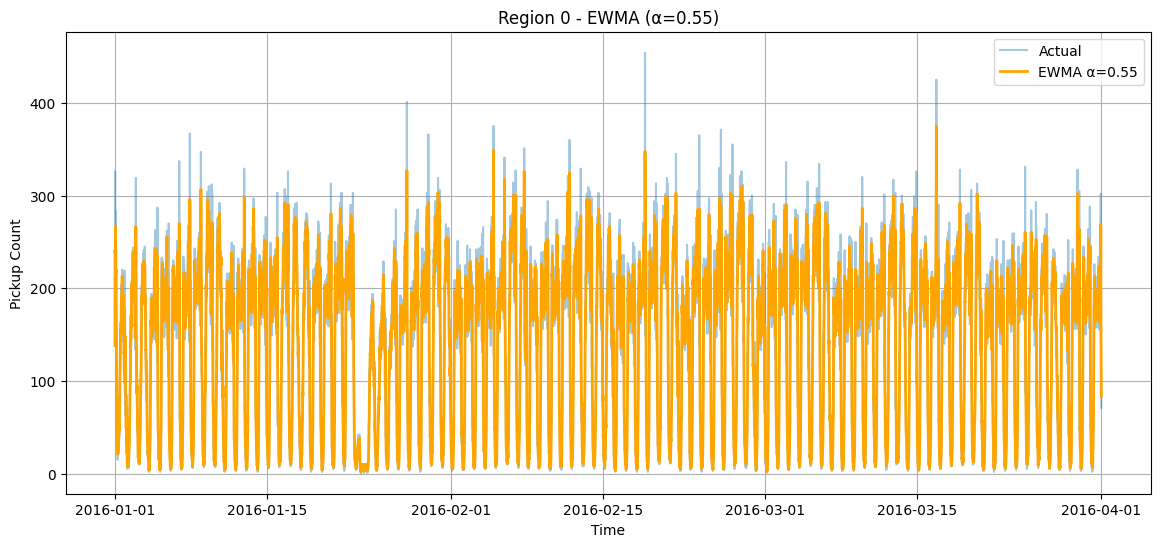

In [82]:
# Pick region with best MAPE
sample_region = int(best_alpha_results.iloc[0]['region'])
best_alpha = best_alpha_results.iloc[0]['best_alpha']

region_data = final_smoothed_df[final_smoothed_df['region'] == sample_region]

plt.figure(figsize=(14,6))
plt.plot(region_data.index, region_data['total_pickups'], label='Actual', alpha=0.4)
plt.plot(region_data.index, region_data['ewma_smoothed'], 
         label=f'EWMA α={best_alpha:.2f}', linewidth=2, color='orange')

plt.title(f"Region {sample_region} - EWMA (α={best_alpha:.2f})")
plt.xlabel("Time")
plt.ylabel("Pickup Count")
plt.legend()
plt.grid(True)
plt.show()


In [86]:
final_smoothed_df.rename(columns={'ewma_smoothed': 'avg_pickups'}, inplace=True)

In [87]:
final_smoothed_df

,region,total_pickups,avg_pickups
tpep_pickup_datetime,,,
2016-01-01 00:00:00,0,138,138.000000
2016-01-01 00:00:00,11,156,156.000000
2016-01-01 00:00:00,14,33,33.000000
2016-01-01 00:00:00,10,126,126.000000
2016-01-01 00:00:00,15,166,166.000000
...,...,...,...
2016-03-31 23:45:00,24,295,295.011212
2016-03-31 23:45:00,25,283,305.794516
2016-03-31 23:45:00,26,317,338.551044


In [89]:
# save the resampled data

resampled_data_save_path = r"D:\datascience\campusx\PROJECTS\demand_preidction_experimentation\data\final_smoothed_time_series.csv"

final_smoothed_df.to_csv(resampled_data_save_path, index=True)